# 🧠 Machine Learning Pipeline Overview

### 1. 📦 Load Necessary Libraries  
Import all required Python packages for data processing, model training, and evaluation.

### 2. 📂 Load Datasets
Datasets were **pre-cleaned and pre-processed**:  
- `train_df` — labeled data for training  
- `val_df` — labeled data for validation (hyperparameter tuning)  
- `test_df` — labeled data for final evaluation  
- `unlabeled_df` — unlabeled data for inference

### 3: Train on TF-IDF
- **Feature Engineering** (Text vectorization using TF-IDF, n-grams and feature selection)
- **Grid Search** for hyperparameter tuning using cross-validation (`min_df`, `C`, `l1_ratio`)
- Train a **One-vs-Rest Logistic Regression classifier** on TF-IDF features (`OneVsRestClassifier(LogisticRegression())`)
- **Threshold Optimization**
- **Evaluate model** with metrics:  
  - Precision  
  - Recall  
  - F1-score  
  - Micro average  
  - Macro average  
  - Weighted average  
  - Samples average
  
### 4: Train on Embedding
- Modeling (**Label-based fine-tuning of Transformer model** (`sentence-transformers/paraphrase-multilingual-mpnet-base-v2`))
- **Feature Extraction** (fine-tuned sentence-transformers/paraphrase-multilingual-mpnet-base-v2`)  
- **Feature Engineering** (VarianceThreshold)
- **Grid Search** for hyperparameter tuning using cross-validation (`C`, `l1_ratio` and feature thresholds)
- Train a **One-vs-Rest Logistic Regression classifier** on sentence embeddings  
  (`OneVsRestClassifier(LogisticRegression())`)
- **Threshold Optimization**
- **Evaluate model** with metrics:  
  - Precision  
  - Recall  
  - F1-score  
  - Micro average  
  - Macro average  
  - Weighted average  
  - Samples average
    

### 5. **Model selection:** Evaluate performance and choose the best model based on metrics

### **1. 📦 Load Necessary Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from itertools import product
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import plotly.express as px
import os
import joblib
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score, f1_score
import seaborn as sns

### **2. 📂 Load Datasets**

In [ ]:
# Read the CSV file
train_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\train_df.csv", sep=';') # For training the model using labeled and augmented data

In [ ]:
# Read the CSV file
test_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\test_df.csv", sep=';')# For final testing of the trained model

In [ ]:
# Read the CSV file
val_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\labeled_df.csv", sep=';') # For validation (hyperparameter tuning with cross-validation) using labeled data without augmentation

In [ ]:
# Read the CSV file
unlabeled_df = pd.read_csv("C:\\Users\\Користувач\\Desktop\\NLP_files\\unlabeled_df.xls", sep=';') # DataFrame containing unlabeled data; planned to be labeled using the trained model

In [ ]:
# Combine unlabeled_df and train_df into full_dataset
full_df = pd.concat([unlabeled_df, train_df], ignore_index=True)# For building the TF-IDF vocabulary
full_df = full_df.drop(columns=["Review Date"])
full_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024.0,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...,NaN,NaN,NaN,NaN,NaN
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023.0,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...,NaN,NaN,NaN,NaN,NaN
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023.0,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...,NaN,NaN,NaN,NaN,NaN
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022.0,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...,NaN,NaN,NaN,NaN,NaN
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021.0,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...,NaN,NaN,NaN,NaN,NaN


### 🔠 **3. Train on TF-IDF**

### ⚙️ Feature Engineering

#### TF-IDF Parameter Analysis for Model Training

In this analysis, we aim to understand the vocabulary overlap between **train** and **unlabeled** datasets and investigate how the choice of `min_df` (minimum document frequency) in the TF-IDF vectorizer affects vocabulary size and model performance.

The main goals are:

1. **Token Overlap Analysis:**  
   Compare the unique tokens in train vs. unlabeled datasets to estimate how many words are shared, and how many are exclusive to each set. This helps us understand if the train data covers the vocabulary used in unlabeled reviews.

2. **Vocabulary Size vs `min_df`:**  
   Test different `min_df` values to observe the trade-off between:
   - **Noise reduction:** removing very rare tokens that may not generalize well.
   - **Information loss:** avoiding the removal of valuable but infrequent features.

3. **Impact on Model Quality:**  
   Plot F1 scores (macro and micro) against `min_df` to select an optimal value that balances model performance and vocabulary size.

By combining these steps, we ensure that TF-IDF features capture meaningful signals without being overwhelmed by noise, providing a robust representation for downstream classification tasks.

### 🔤 Vocabulary Overlap Analysis (TF-IDF)

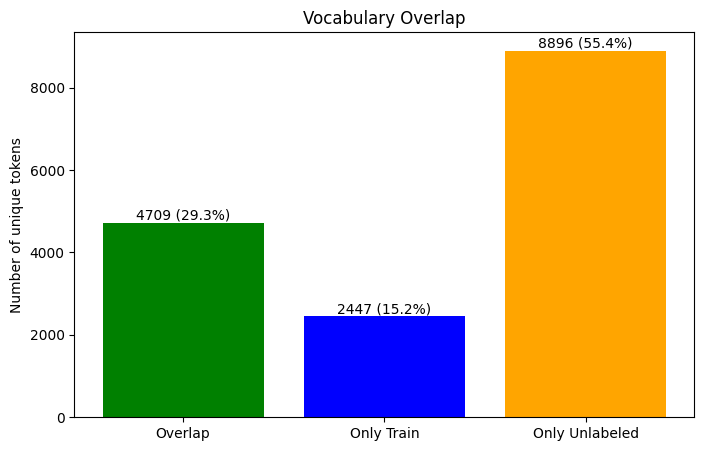

Full vocabulary size: 16052
Overlap tokens: 4709
Only in train: 2447
Only in unlabeled: 8896
Check sum: 16052


In [ ]:
# -----------------------------
# 1️⃣ Prepare text lists
# -----------------------------
texts_train = train_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_unlabeled = unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_full = full_df["Lemmatized_Text"].dropna().astype(str).tolist()

# -----------------------------
# 2️⃣ Build TF-IDF vocabulary on full corpus with n-grams
# -----------------------------
vectorizer = TfidfVectorizer(min_df=1)
vectorizer.fit(texts_full)
full_vocab = set(vectorizer.get_feature_names_out())

# Build analyzer to get the same tokenization for train/unlabeled
analyze = vectorizer.build_analyzer()

tokens_train = set()
for text in texts_train:
    tokens_train.update(analyze(text))

tokens_unlabeled = set()
for text in texts_unlabeled:
    tokens_unlabeled.update(analyze(text))

# -----------------------------
# 3️⃣ Compute overlap and unique tokens
# -----------------------------
overlap = full_vocab & tokens_train & tokens_unlabeled
only_train = (full_vocab & tokens_train) - tokens_unlabeled
only_unlabeled = (full_vocab & tokens_unlabeled) - tokens_train
# -----------------------------
# 4️⃣ Counts and percentages
# -----------------------------
total_tokens = len(full_vocab)
labels = ["Overlap", "Only Train", "Only Unlabeled"]
counts = [len(overlap), len(only_train), len(only_unlabeled)]
percentages = [c/total_tokens*100 for c in counts]

# -----------------------------
# 5️⃣ Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color=["green", "blue", "orange"])
plt.title("Vocabulary Overlap")
plt.ylabel("Number of unique tokens")

# Add count + percentage labels above bars
for i, (c, p) in enumerate(zip(counts, percentages)):
    plt.text(i, c + total_tokens*0.005, f"{c} ({p:.1f}%)", ha='center')

plt.show()

# -----------------------------
# 6️⃣ Summary
# -----------------------------
print("Full vocabulary size:", total_tokens)
print("Overlap tokens:", len(overlap))
print("Only in train:", len(only_train))
print("Only in unlabeled:", len(only_unlabeled))
print("Check sum:", len(overlap) + len(only_train) + len(only_unlabeled))


### 📊 Vocabulary Size vs `min_df`

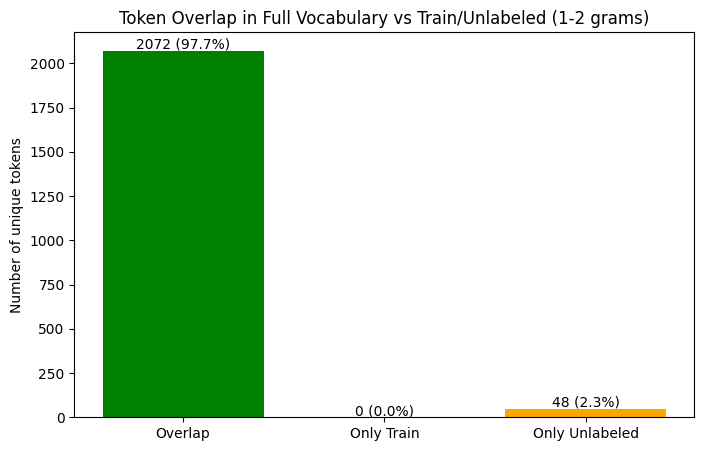

Full vocabulary size: 2120
Overlap tokens: 2072
Only in train: 0
Only in unlabeled: 48
Check sum: 2120


In [ ]:
# -----------------------------
# 1️⃣ Prepare text lists
# -----------------------------
texts_train = train_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_unlabeled = unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist()
texts_full = full_df["Lemmatized_Text"].dropna().astype(str).tolist()

# -----------------------------
# 2️⃣ Build TF-IDF vocabulary on full corpus with n-grams
# -----------------------------
vectorizer = TfidfVectorizer(min_df=10, ngram_range=(1, 2))
vectorizer.fit(texts_full)
full_vocab = set(vectorizer.get_feature_names_out())

# Build analyzer to get the same tokenization for train/unlabeled
analyze = vectorizer.build_analyzer()

tokens_train = set()
for text in texts_train:
    tokens_train.update(analyze(text))

tokens_unlabeled = set()
for text in texts_unlabeled:
    tokens_unlabeled.update(analyze(text))

# -----------------------------
# 3️⃣ Compute overlap and unique tokens
# -----------------------------
overlap = full_vocab & tokens_train & tokens_unlabeled
only_train = (full_vocab & tokens_train) - tokens_unlabeled
only_unlabeled = (full_vocab & tokens_unlabeled) - tokens_train

# -----------------------------
# 4️⃣ Counts and percentages
# -----------------------------
total_tokens = len(full_vocab)
labels = ["Overlap", "Only Train", "Only Unlabeled"]
counts = [len(overlap), len(only_train), len(only_unlabeled)]
percentages = [c/total_tokens*100 for c in counts]

# -----------------------------
# 5️⃣ Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.bar(labels, counts, color=["green", "blue", "orange"])
plt.title("Token Overlap in Full Vocabulary vs Train/Unlabeled (1-2 grams)")
plt.ylabel("Number of unique tokens")

# Add count + percentage labels above bars
for i, (c, p) in enumerate(zip(counts, percentages)):
    plt.text(i, c + total_tokens*0.005, f"{c} ({p:.1f}%)", ha='center')

plt.show()

# -----------------------------
# 6️⃣ Summary
# -----------------------------
print("Full vocabulary size:", total_tokens)
print("Overlap tokens:", len(overlap))
print("Only in train:", len(only_train))
print("Only in unlabeled:", len(only_unlabeled))
print("Check sum:", len(overlap) + len(only_train) + len(only_unlabeled))

### 📉  **Compare Vocabulary Size vs `min_df`**
- Analyze how the vocabulary size changes with different `min_df` values
- Use a TF-IDF vectorizer with unigrams and bigrams

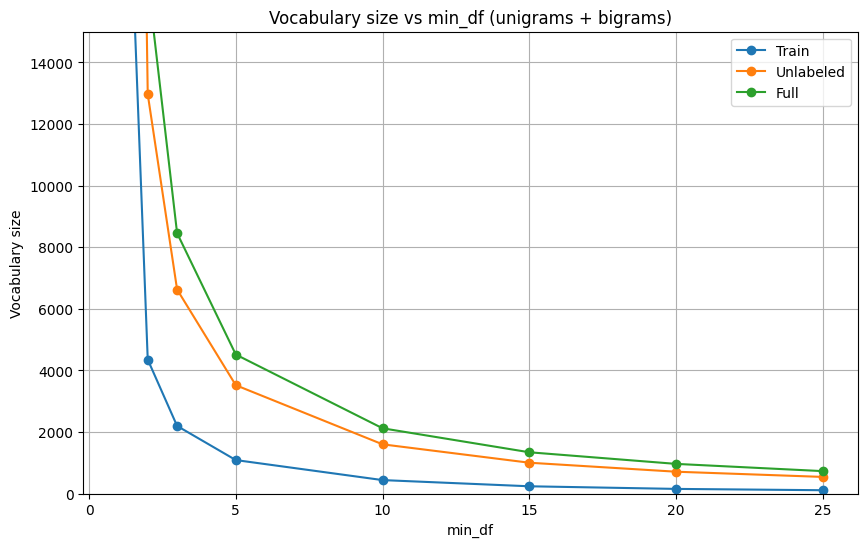

In [ ]:
corpora = {
    "Train": train_df["Lemmatized_Text"].dropna().astype(str).tolist(),
    "Unlabeled": unlabeled_df["Lemmatized_Text"].dropna().astype(str).tolist(),
    "Full": full_df["Lemmatized_Text"].dropna().astype(str).tolist()
}

# New min_df values to test
min_dfs = [1, 2, 3, 5, 10, 15, 20, 25]
results = {name: [] for name in corpora}

# Compute vocabulary size for each min_df and corpus
for min_df in min_dfs:
    for name, texts in corpora.items():
        vectorizer = TfidfVectorizer(min_df=min_df, ngram_range=(1, 2))  # unigrams + bigrams
        vectorizer.fit(texts)
        vocab_size = len(vectorizer.vocabulary_)
        results[name].append(vocab_size)

# Plot vocabulary size vs min_df
plt.figure(figsize=(10,6))
for name, vocab_sizes in results.items():
    plt.plot(min_dfs, vocab_sizes, marker="o", label=name)

plt.title("Vocabulary size vs min_df (unigrams + bigrams)")
plt.xlabel("min_df")
plt.ylabel("Vocabulary size")
plt.ylim(0, 15000)  # limit to 15k
plt.legend()
plt.grid(True)
plt.show()

### 📈 Impact on Model Quality


=== Evaluating min_df = 1 ===
Macro F1 = 0.6355, Micro F1 = 0.6359

=== Evaluating min_df = 2 ===
Macro F1 = 0.6354, Micro F1 = 0.6364

=== Evaluating min_df = 3 ===
Macro F1 = 0.6359, Micro F1 = 0.6349

=== Evaluating min_df = 5 ===
Macro F1 = 0.6455, Micro F1 = 0.6447

=== Evaluating min_df = 10 ===
Macro F1 = 0.6492, Micro F1 = 0.6498

=== Evaluating min_df = 15 ===
Macro F1 = 0.6519, Micro F1 = 0.6516

=== Evaluating min_df = 17 ===
Macro F1 = 0.6523, Micro F1 = 0.6518

=== Evaluating min_df = 20 ===
Macro F1 = 0.6510, Micro F1 = 0.6499

=== Evaluating min_df = 21 ===
Macro F1 = 0.6491, Micro F1 = 0.6485

=== Evaluating min_df = 22 ===
Macro F1 = 0.6559, Micro F1 = 0.6564

=== Evaluating min_df = 23 ===
Macro F1 = 0.6515, Micro F1 = 0.6520

=== Evaluating min_df = 24 ===
Macro F1 = 0.6461, Micro F1 = 0.6465

=== Evaluating min_df = 25 ===
Macro F1 = 0.6461, Micro F1 = 0.6471


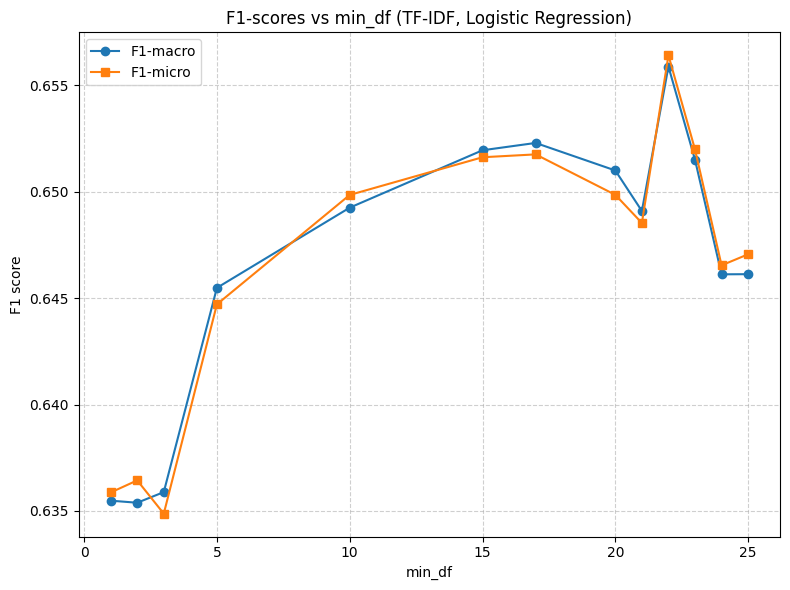

In [ ]:
# Label columns (multi-label setup)
label_cols = ["Attitude_Towards_Students", "Campus_conditions", "Corruption",
              "Academic_Process_Management", "Education_Quality"]

# Range of min_df values to test
min_dfs = [1, 2, 3, 5, 10, 15, 17, 20, 21, 22, 23, 24, 25]

# Results storage
results = {"min_df": [], "f1_macro": [], "f1_micro": []}

# ---------------------------------
# Iterate over different min_df values
# ---------------------------------
for min_df in min_dfs:
    print(f"\n=== Evaluating min_df = {min_df} ===")

    # 1. Vectorize full corpus
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=min_df
    )
    vectorizer.fit(full_df["Lemmatized_Text"])

    # 2. Transform labeled texts
    X_labeled = vectorizer.transform(val_df["Lemmatized_Text"])
    y_labeled = val_df[label_cols].values

    # 3. Cross-validation setup
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    y_val_all, y_pred_all = [], []

    # 4. Perform CV
    for tr_idx, val_idx in kf.split(X_labeled):
        X_tr, X_val = X_labeled[tr_idx], X_labeled[val_idx]
        y_tr, y_val = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=1000,
                penalty="elasticnet",
                solver="saga",
                class_weight="balanced",
                l1_ratio=0.5,
                C=2
            )
        )
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)

        y_val_all.append(y_val)
        y_pred_all.append(y_pred)

    # 5. Evaluation
    y_val_all = np.vstack(y_val_all)
    y_pred_all = np.vstack(y_pred_all)

    f1_macro = f1_score(y_val_all, y_pred_all, average="macro")
    f1_micro = f1_score(y_val_all, y_pred_all, average="micro")

    print(f"Macro F1 = {f1_macro:.4f}, Micro F1 = {f1_micro:.4f}")

    results["min_df"].append(min_df)
    results["f1_macro"].append(f1_macro)
    results["f1_micro"].append(f1_micro)

# ---------------------------------
# Plot F1-scores vs min_df
# ---------------------------------
plt.figure(figsize=(8, 6))
plt.plot(results["min_df"], results["f1_macro"], marker="o", label="F1-macro")
plt.plot(results["min_df"], results["f1_micro"], marker="s", label="F1-micro")

plt.title("F1-scores vs min_df (TF-IDF, Logistic Regression)")
plt.xlabel("min_df")
plt.ylabel("F1 score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Observation

After experimenting with different `min_df` values, we observed the following:

- Lower `min_df` values (e.g., 1–5)  
  - Include many **rare tokens** that appear only a few times.  
  - This increases the **vocabulary size** but also introduces **noise** into the model.

- Higher `min_df` values (e.g., 22+)  
  - Start to trim **valuable tokens** even from the full dataset.  
  - Potentially lose **informative features**.

### ⚙️ Grid Search for hyperparameter tuning

Running min_df=5, l1_ratio=0.2, C=1.0
Running min_df=5, l1_ratio=0.2, C=1.5
Running min_df=5, l1_ratio=0.2, C=2.0
Running min_df=5, l1_ratio=0.2, C=2.5
Running min_df=5, l1_ratio=0.4, C=1.0
Running min_df=5, l1_ratio=0.4, C=1.5
Running min_df=5, l1_ratio=0.4, C=2.0
Running min_df=5, l1_ratio=0.4, C=2.5
Running min_df=5, l1_ratio=0.6, C=1.0
Running min_df=5, l1_ratio=0.6, C=1.5
Running min_df=5, l1_ratio=0.6, C=2.0
Running min_df=5, l1_ratio=0.6, C=2.5
Running min_df=5, l1_ratio=0.8, C=1.0
Running min_df=5, l1_ratio=0.8, C=1.5
Running min_df=5, l1_ratio=0.8, C=2.0
Running min_df=5, l1_ratio=0.8, C=2.5
Running min_df=10, l1_ratio=0.2, C=1.0
Running min_df=10, l1_ratio=0.2, C=1.5
Running min_df=10, l1_ratio=0.2, C=2.0
Running min_df=10, l1_ratio=0.2, C=2.5
Running min_df=10, l1_ratio=0.4, C=1.0
Running min_df=10, l1_ratio=0.4, C=1.5
Running min_df=10, l1_ratio=0.4, C=2.0
Running min_df=10, l1_ratio=0.4, C=2.5
Running min_df=10, l1_ratio=0.6, C=1.0
Running min_df=10, l1_ratio=0.6, C=1.5
Ru

,min_df,l1_ratio,C,n_features,f1_micro_train,f1_micro_val
47,12,0.8,2.5,1710,0.887498,0.658332
43,12,0.6,2.5,1710,0.918824,0.656774
38,12,0.4,2.0,1710,0.924977,0.656466
103,22,0.4,2.5,850,0.938798,0.656059
101,22,0.4,1.5,850,0.872795,0.654856
59,15,0.6,2.5,1341,0.917308,0.654194
102,22,0.4,2.0,850,0.919592,0.654017
87,20,0.4,2.5,964,0.941895,0.653869
94,20,0.8,2.0,964,0.852771,0.653090
107,22,0.6,2.5,850,0.913282,0.653035


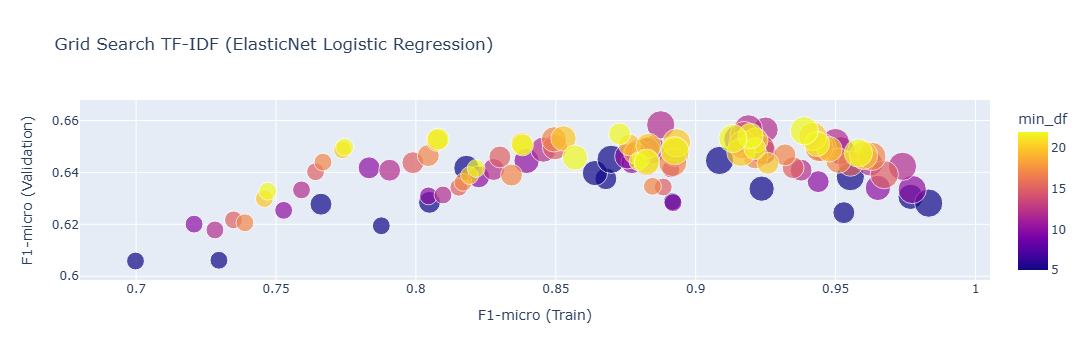

In [ ]:
# -----------------------------
# Label columns
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]
y_labeled = val_df[label_cols].values

# -----------------------------
# Grid parameters
# -----------------------------
min_dfs = [5, 10, 12, 15, 17, 20, 22]
l1_ratios = [0.2, 0.4, 0.6, 0.8]
Cs = [1.0, 1.5, 2.0, 2.5]

# -----------------------------
# Store results
# -----------------------------
results = {
    "min_df": [],
    "l1_ratio": [],
    "C": [],
    "n_features": [],
    "f1_micro_train": [],
    "f1_micro_val": []
}

# -----------------------------
# Grid search loop
# -----------------------------
for min_df, l1_ratio, C in product(min_dfs, l1_ratios, Cs):
    print(f"Running min_df={min_df}, l1_ratio={l1_ratio}, C={C}")

    # 1️⃣ TF-IDF vectorization
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        min_df=min_df
    )
    vectorizer.fit(full_df["Lemmatized_Text"])
    X_tfidf = vectorizer.transform(val_df["Lemmatized_Text"])

    # 2️⃣ Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    f1_train_list, f1_val_list = [], []

    for tr_idx, val_idx in kf.split(X_tfidf):
        X_tr, X_val_fold = X_tfidf[tr_idx], X_tfidf[val_idx]
        y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                penalty="elasticnet",
                l1_ratio=l1_ratio,
                C=C,
                random_state=42
            )
        )

        clf.fit(X_tr, y_tr)
        y_tr_pred = clf.predict(X_tr)
        y_val_pred = clf.predict(X_val_fold)

        f1_train_list.append(f1_score(y_tr, y_tr_pred, average="micro"))
        f1_val_list.append(f1_score(y_val_fold, y_val_pred, average="micro"))

    # 3️⃣ Save averaged results
    results["min_df"].append(min_df)
    results["l1_ratio"].append(l1_ratio)
    results["C"].append(C)
    results["n_features"].append(X_tfidf.shape[1])
    results["f1_micro_train"].append(np.mean(f1_train_list))
    results["f1_micro_val"].append(np.mean(f1_val_list))

# -----------------------------
# Convert results to DataFrame
# -----------------------------
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values("f1_micro_val", ascending=False)
display(df_results_sorted.head(10))

# -----------------------------
#  Visualization
# -----------------------------
fig = px.scatter(
    df_results,
    x="f1_micro_train",
    y="f1_micro_val",
    color="min_df",
    size="C",
    hover_data=["min_df", "l1_ratio", "C", "n_features"],
    title="Grid Search TF-IDF (ElasticNet Logistic Regression)",
)
fig.update_layout(
    xaxis_title="F1-micro (Train)",
    yaxis_title="F1-micro (Validation)"
)
fig.show()


#### 🧩 **Grid Search Conclusion**

The best hyperparameters for the TF-IDF vectorizer were selected as:  

- **min_df = 12**  
- **C = 0.8**  
- **l1_ratio = 2.5**   

### 🤖 Model Training & Evaluation

In [ ]:
# -----------------------------
# 1️⃣ Label columns
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------------
# 2️⃣ TF-IDF vectorization (best params from grid search)
# -----------------------------
best_min_df = 12
best_l1_ratio = 0.8
best_C = 2.5

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=best_min_df
)
vectorizer.fit(full_df["Lemmatized_Text"])

X_train_tfidf = vectorizer.transform(train_df["Lemmatized_Text"])
X_val_tfidf   = vectorizer.transform(val_df["Lemmatized_Text"])
X_test_tfidf  = vectorizer.transform(test_df["Lemmatized_Text"])

y_train = train_df[label_cols].values
y_val   = val_df[label_cols].values
y_test  = test_df[label_cols].values

# -----------------------------
# 3️⃣ Cross-Validation on Validation Set
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_pred_all = []

for tr_idx, val_idx in kf.split(X_val_tfidf):
    X_tr, X_val_fold = X_val_tfidf[tr_idx], X_val_tfidf[val_idx]
    y_tr, y_val_fold = y_val[tr_idx], y_val[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=best_l1_ratio,
            C=best_C,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)
    y_val_pred = clf.predict(X_val_fold)

    y_val_all.append(y_val_fold)
    y_pred_all.append(y_val_pred)

# aggregate predictions
y_val_all = np.vstack(y_val_all)
y_pred_all = np.vstack(y_pred_all)

print("\n=== CV Classification Report (Validation TF-IDF) ===")
print(classification_report(y_val_all, y_pred_all, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_pred_all, average="micro")
print(f"Aggregated CV micro-F1: {cv_micro:.3f}")

# -----------------------------
# 4️⃣ Train/Test Evaluation
# -----------------------------
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=best_l1_ratio,
        C=best_C,
        random_state=42
    )
)

clf.fit(X_train_tfidf, y_train)


# TRAIN
y_train_pred = clf.predict(X_train_tfidf)
print("\n=== TRAIN RESULTS ===")
print(classification_report(y_train, y_train_pred, target_names=label_cols, digits=2))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")

# TEST
y_test_pred = clf.predict(X_test_tfidf)
print("\n=== TEST RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=label_cols, digits=2))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")



=== CV Classification Report (Validation TF-IDF) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.65      0.59      0.62       145
          Campus_conditions       0.78      0.63      0.70       108
                 Corruption       0.77      0.66      0.71       133
Academic_Process_Management       0.60      0.54      0.57       130
          Education_Quality       0.71      0.68      0.70       184

                  micro avg       0.70      0.63      0.66       700
                  macro avg       0.70      0.62      0.66       700
               weighted avg       0.70      0.63      0.66       700
                samples avg       0.61      0.64      0.60       700

Aggregated CV micro-F1: 0.659

=== TRAIN RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.87      0.92      0.90       205
          Campus_conditions       0.85      0.96      0.90   

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.



### 📈 Train vs Test F1 per Class

In [ ]:
# List of classes
classes = label_cols

# Compute F1-score for each class individually
f1_train_per_class = [f1_score(y_train[:, i], y_train_pred[:, i]) for i in range(len(classes))]
f1_test_per_class  = [f1_score(y_test[:, i],  y_test_pred[:, i])  for i in range(len(classes))]

# Plot F1-scores for each class (Train vs Test)
plt.figure(figsize=(8,5))
plt.plot(classes, f1_train_per_class, marker='o', label='Train F1')
plt.plot(classes, f1_test_per_class, marker='o', label='Test F1')
plt.ylim(0,1)
plt.ylabel('F1-score')
plt.title('Train vs Test F1 per class')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### ⚖️ Threshold Optimization

In [ ]:
# -----------------------------
# K-Fold CV зі збором proba
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_prob_all = []

for tr_idx, val_idx in kf.split(X_val_tfidf):
    X_tr, X_val_fold = X_val_tfidf[tr_idx], X_val_tfidf[val_idx]
    y_tr, y_val_fold = y_val[tr_idx], y_val[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.8,
            C=2.5,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)

    # Збираємо ймовірності для підбору threshold
    y_val_prob = np.array([est.predict_proba(X_val_fold)[:,1] for est in clf.estimators_]).T

    y_val_all.append(y_val_fold)
    y_prob_all.append(y_val_prob)

# -----------------------------
# Aggregate across folds
# -----------------------------
y_val_all = np.vstack(y_val_all)
y_prob_all = np.vstack(y_prob_all)

# -----------------------------
# Підбір optimal threshold для кожної мітки
# -----------------------------
optimal_thresholds = []

for i in range(y_val_all.shape[1]):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.1, 0.91, 0.01):
        y_pred_bin = (y_prob_all[:, i] > thresh).astype(int)
        f1 = f1_score(y_val_all[:, i], y_pred_bin)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    optimal_thresholds.append(best_thresh)
    print(f"Label {label_cols[i]}: optimal threshold = {best_thresh:.2f}, F1 = {best_f1:.3f}")

# -----------------------------
# Використання optimal thresholds
# -----------------------------
y_val_pred_opt = np.zeros_like(y_prob_all, dtype=int)
for i, thresh in enumerate(optimal_thresholds):
    y_val_pred_opt[:, i] = (y_prob_all[:, i] > thresh).astype(int)

print("\n=== CV Classification Report WITH OPTIMAL THRESHOLDS ===")
print(classification_report(y_val_all, y_val_pred_opt, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_val_pred_opt, average="micro")
print(f"Aggregated CV micro-F1 (optimal thresholds): {cv_micro:.4f}")


Label Attitude_Towards_Students: optimal threshold = 0.43, F1 = 0.624
Label Campus_conditions: optimal threshold = 0.44, F1 = 0.737
Label Corruption: optimal threshold = 0.49, F1 = 0.712
Label Academic_Process_Management: optimal threshold = 0.40, F1 = 0.573
Label Education_Quality: optimal threshold = 0.44, F1 = 0.701

=== CV Classification Report WITH OPTIMAL THRESHOLDS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.56      0.71      0.62       145
          Campus_conditions       0.76      0.71      0.74       108
                 Corruption       0.76      0.67      0.71       133
Academic_Process_Management       0.50      0.68      0.57       130
          Education_Quality       0.64      0.78      0.70       184

                  micro avg       0.62      0.71      0.66       700
                  macro avg       0.64      0.71      0.67       700
               weighted avg       0.64      0.71      0.67       70

### 📉 CV Predicted Probabilities and Threshold Plots

✅ Collected 500 examples from cross-validation.


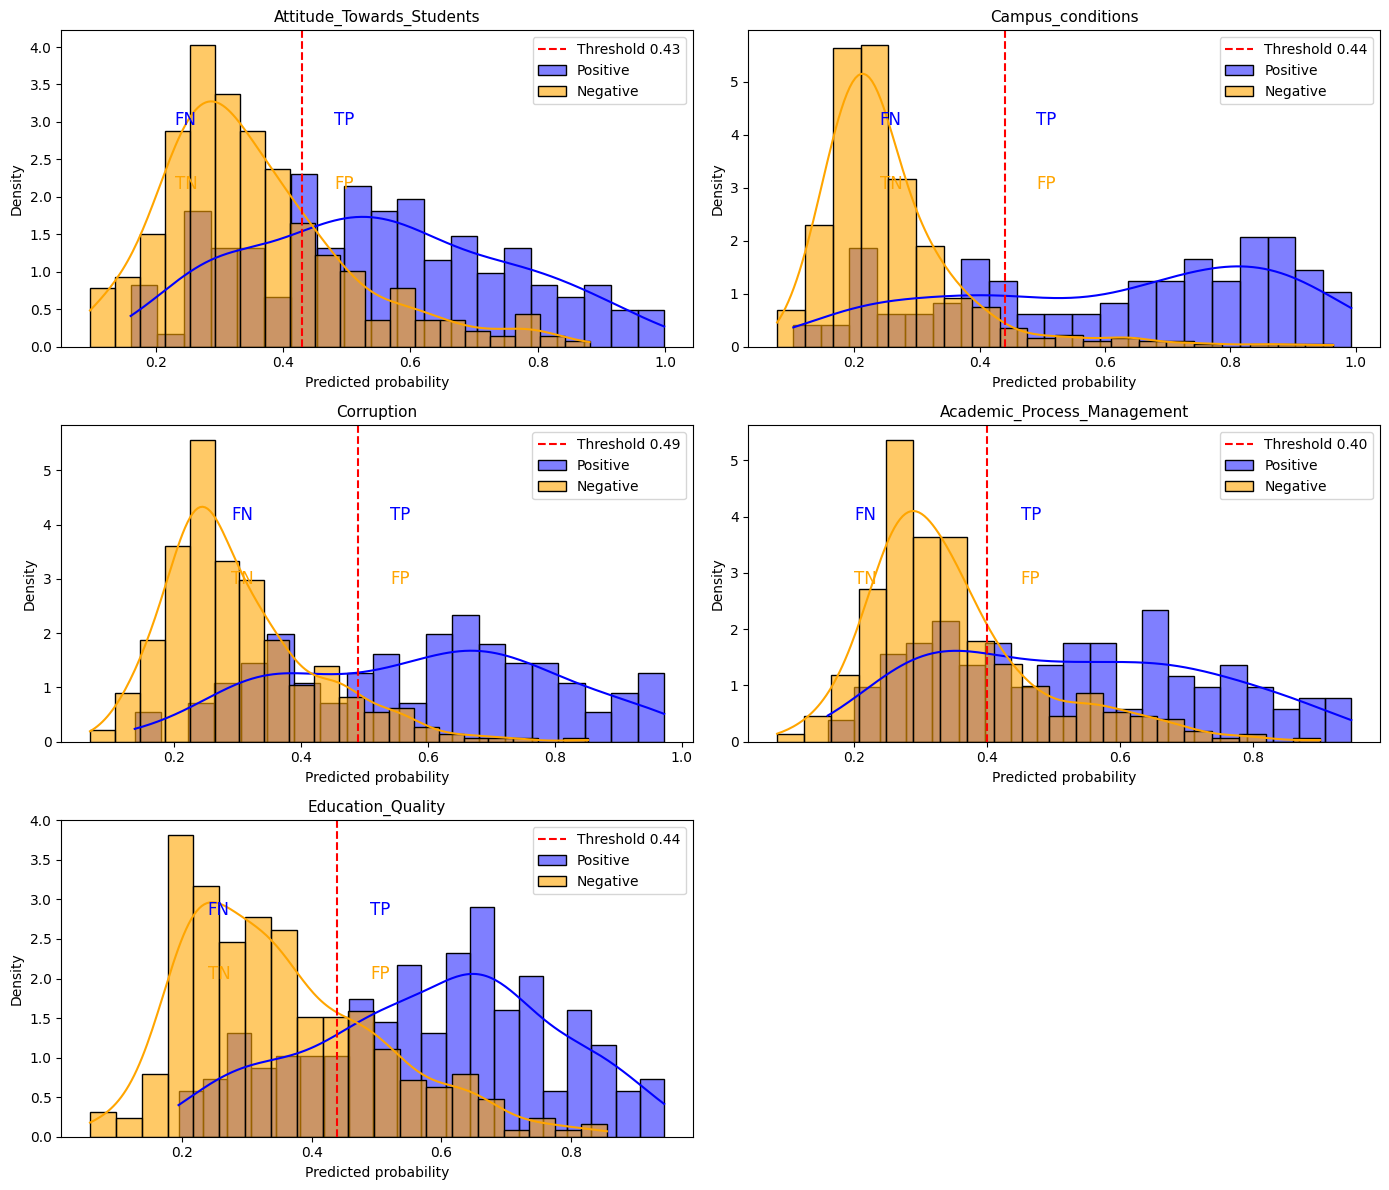

In [ ]:
# -----------------------------
# 1️⃣ Parameters
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Pre-selected optimal thresholds for each class
optimal_thresholds = [0.43, 0.44, 0.49, 0.40, 0.44]

# -----------------------------
# 2️⃣ Cross-validation to collect predicted probabilities
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_val_all = []
y_prob_all = []

for tr_idx, val_idx in kf.split(X_val_tfidf):
    X_tr, X_val_fold = X_val_tfidf[tr_idx], X_val_tfidf[val_idx]
    y_tr, y_val_fold = y_val[tr_idx], y_val[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.8,
            C=2.5,
            random_state=42
        )
    )
    clf.fit(X_tr, y_tr)

    probs_output = clf.predict_proba(X_val_fold)
    if isinstance(probs_output, list):
        y_prob_fold = np.column_stack([m[:, 1] for m in probs_output])
    else:
        y_prob_fold = probs_output

    y_prob_all.append(y_prob_fold)
    y_val_all.append(y_val_fold)

y_val_all = np.vstack(y_val_all)
y_prob_all = np.vstack(y_prob_all)

print(f"✅ Collected {len(y_val_all)} examples from cross-validation.")

# -----------------------------
# 3️⃣ Visualization with TP/FP/TN/FN
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, label in enumerate(label_cols):
    ax = axes[i]
    probs = y_prob_all[:, i]
    y_true = y_val_all[:, i]
    threshold = optimal_thresholds[i]

    # Plot positive and negative distributions
    sns.histplot(probs[y_true == 1], color='blue', label='Positive', kde=True, bins=20, stat='density', ax=ax)
    sns.histplot(probs[y_true == 0], color='orange', label='Negative', kde=True, bins=20, stat='density', ax=ax, alpha=0.6)

    # Draw threshold line
    ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold {threshold:.2f}')

    # TP, FN, FP, TN masks
    TP_mask = (y_true == 1) & (probs >= threshold)
    FN_mask = (y_true == 1) & (probs < threshold)
    FP_mask = (y_true == 0) & (probs >= threshold)
    TN_mask = (y_true == 0) & (probs < threshold)

    # Annotate TP, FN, FP, TN areas
    ymax = ax.get_ylim()[1]
    ax.text(threshold + 0.05, ymax*0.7, 'TP', color='blue', fontsize=12)
    ax.text(threshold - 0.2, ymax*0.7, 'FN', color='blue', fontsize=12)
    ax.text(threshold + 0.05, ymax*0.5, 'FP', color='orange', fontsize=12)
    ax.text(threshold - 0.2, ymax*0.5, 'TN', color='orange', fontsize=12)

    # Titles and labels
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.legend()

# Remove extra subplots if any
if len(label_cols) < len(axes):
    for j in range(len(label_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 🎯 Evaluate model performance with individual thresholds on train/test sets

In [ ]:

# ==========================================
# BLOCK 2: Train classifier
# ==========================================
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.8,
        C=2.5,
        random_state=42
    )
)

clf.fit(X_train_tfidf, y_train)

# ==========================================
# BLOCK 3: Evaluate with optimal thresholds
# ==========================================
# Thresholds підібрані на CV
optimal_thresholds = [0.43, 0.44, 0.49, 0.40, 0.44]

# --- TRAIN SET ---
y_train_prob = np.array([est.predict_proba(X_train_tfidf)[:,1] for est in clf.estimators_]).T
y_train_pred_opt = np.zeros_like(y_train_prob, dtype=int)
for i, thresh in enumerate(optimal_thresholds):
    y_train_pred_opt[:, i] = (y_train_prob[:, i] > thresh).astype(int)

print("\n=== TRAIN SET RESULTS (with optimal thresholds) ===")
print(classification_report(y_train, y_train_pred_opt, target_names=label_cols, digits=2, zero_division=0))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred_opt, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred_opt, average='macro'):.3f}")

# --- TEST SET ---
y_test_prob = np.array([est.predict_proba(X_test_tfidf)[:,1] for est in clf.estimators_]).T
y_test_pred_opt = np.zeros_like(y_test_prob, dtype=int)
for i, thresh in enumerate(optimal_thresholds):
    y_test_pred_opt[:, i] = (y_test_prob[:, i] > thresh).astype(int)

print("\n=== TEST SET RESULTS (with optimal thresholds) ===")
print(classification_report(y_test, y_test_pred_opt, target_names=label_cols, digits=2, zero_division=0))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred_opt, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred_opt, average='macro'):.3f}")

# ==========================================
# BLOCK 4: Save models
# ==========================================
os.makedirs("models", exist_ok=True)
joblib.dump(clf, "models/logreg_classifier_tfidf.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

print("\n✅ Classifier saved to: models/logreg_classifier_tfidf.pkl")
print("✅ TF-IDF vectorizer saved to: models/tfidf_vectorizer.pkl")



=== TRAIN SET RESULTS (with optimal thresholds) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.80      0.97      0.87       205
          Campus_conditions       0.83      0.97      0.89       108
                 Corruption       0.88      0.98      0.93       133
Academic_Process_Management       0.76      0.98      0.86       190
          Education_Quality       0.78      0.98      0.87       184

                  micro avg       0.80      0.98      0.88       820
                  macro avg       0.81      0.98      0.88       820
               weighted avg       0.80      0.98      0.88       820
                samples avg       0.85      0.98      0.89       820

Train Micro F1: 0.880
Train Macro F1: 0.885

=== TEST SET RESULTS (with optimal thresholds) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.48      0.74      0.58        31
          Campus_co

### 🧠 **4. Train on Embedding**

### ⚡ Model Fine-Tuning

In [ ]:
# =========================
# BLOCK 0: Imports & device
# =========================
os.makedirs("embeddings", exist_ok=True)  # створює папку, якщо її нема

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# BLOCK 1: Load base model
# =========================
# Transformer + Pooling
word_embedding_model = models.Transformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
base_model = SentenceTransformer(modules=[word_embedding_model, pooling_model]).to(device)

# =========================
# BLOCK 2: Fine-tuning setup
# =========================
import torch.nn as nn

embedding_dim = base_model.get_sentence_embedding_dimension()
num_classes = len(label_cols)

# Multi-label classifier
class MultiLabelClassifier(nn.Module):
    def __init__(self, base_model, embedding_dim, num_classes):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(embedding_dim, num_classes)
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, sentences, labels=None):
        embeddings = self.base_model.encode(
            sentences, convert_to_tensor=True, device=device
        )
        embeddings = embeddings.clone().detach().requires_grad_(True)
        logits = self.classifier(embeddings)
        if labels is not None:
            labels = torch.tensor(labels, dtype=torch.float, device=device)
            loss = self.loss_fn(logits, labels)
            return loss
        return logits

model = MultiLabelClassifier(base_model, embedding_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# =========================
# BLOCK 3: Fine-tuning loop
# =========================
num_epochs = 2
model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for text, label in zip(train_df["Cleaned_Text"], train_df[label_cols].values):
        optimizer.zero_grad()
        loss = model([text], [label.tolist()])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs} — Avg Loss: {total_loss/len(train_df):.4f}")

# =========================
# BLOCK 4: Save fine-tuned model
# =========================
save_path = "/content/drive/MyDrive/models/fine_tuned_mpnet"
base_model.save(save_path)
print(f"Model saved to: {save_path}")

# =========================
# BLOCK 5: Generate embeddings
# =========================
train_emb = base_model.encode(train_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)
val_emb   = base_model.encode(val_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)
test_emb  = base_model.encode(test_df["Cleaned_Text"], convert_to_numpy=True, show_progress_bar=True)

# =========================
# BLOCK 6: Save embeddings
# =========================
np.save("embeddings/train_embeddings.npy", train_emb)
np.save("embeddings/val_embeddings.npy", val_emb)
np.save("embeddings/test_embeddings.npy", test_emb)
print("Embeddings saved to disk.")



Epoch 1/2 — Avg Loss: 0.6793
Epoch 2/2 — Avg Loss: 0.6526
Model saved to: /content/drive/MyDrive/models/fine_tuned_mpnet


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embeddings saved to disk.


### 🛠️ Feature Extraction & Feature Engineering

In [ ]:
# Loading embeddings
train_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/train_embeddings.npy")
test_emb  = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/test_embeddings.npy")
val_emb = np.load("C:/Users/Користувач/Desktop/NLP_files/embeddings/val_embeddings.npy")

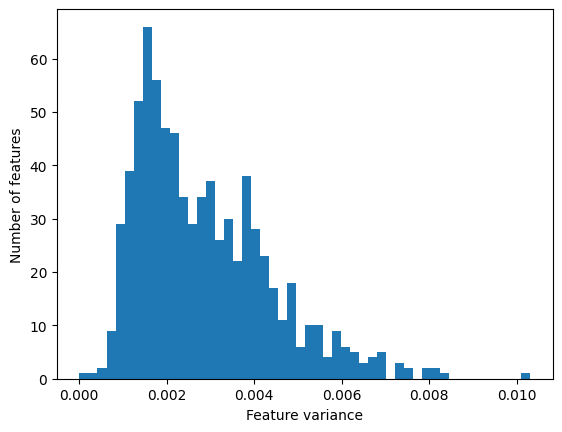

10% ознак мають дисперсію < 0.00122
25% ознак мають дисперсію < 0.00162
50% ознак мають дисперсію < 0.00249
75% ознак мають дисперсію < 0.00383
90% ознак мають дисперсію < 0.00491


In [ ]:
# Calculate the variance for each embedding dimension
variances = train_emb.var(axis=0)

# Import the plotting library
import matplotlib.pyplot as plt

# Plot a histogram of the variances
plt.hist(variances, bins=50)

# Label the x-axis (Feature variance)
plt.xlabel("Feature variance")

# Label the y-axis (Number of features)
plt.ylabel("Number of features")

# Display the plot
plt.show()

for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"{int(q*100)}% ознак мають дисперсію < {np.quantile(variances, q):.5f}")

In [ ]:
# -----------------------------
# 1️⃣ Set up Variance Threshold
# -----------------------------
threshold = 0.003
selector = VarianceThreshold(threshold=threshold)

# Fit selector on TRAIN embeddings only
train_emb_reduced = selector.fit_transform(train_emb)

# Apply same feature mask to TEST and VAL
test_emb_reduced = selector.transform(test_emb)
val_emb_reduced = selector.transform(val_emb)

print("Original number of features:", train_emb.shape[1])
print("Number of features after VarianceThreshold:", train_emb_reduced.shape[1])
print("Number of features removed:", train_emb.shape[1] - train_emb_reduced.shape[1])

Original number of features: 768
Number of features after VarianceThreshold: 304
Number of features removed: 464


### ⚙️ Grid Search

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold
from scipy.sparse import csr_matrix

# -----------------------------
# Settings
# -----------------------------
thresholds = [0.0012, 0.002, 0.003, 0.004, 0.005]
l1_ratios = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
Cs = [0.5, 1, 1.5, 2, 2.5]

results = []

# Load data (assumed to be already in memory)
# val_emb, y_labeled — from your previous examples
X_emb_sparse = csr_matrix(val_emb)
y_labeled = val_df[label_cols].values

# -----------------------------
# Cross-validation setup
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Grid Search: thresholds × l1_ratios × Cs
# -----------------------------
for t, l1_ratio, C in product(thresholds, l1_ratios, Cs):
    print(f"Running threshold={t}, l1_ratio={l1_ratio}, C={C}")

    selector = VarianceThreshold(threshold=t)
    X_reduced = selector.fit_transform(val_emb)

    f1_train_list, f1_val_list = [], []

    for tr_idx, val_idx in kf.split(X_reduced):
        X_tr, X_val_fold = X_reduced[tr_idx], X_reduced[val_idx]
        y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

        clf = OneVsRestClassifier(
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                penalty="elasticnet",
                l1_ratio=l1_ratio,
                C=C,
                random_state=42
            )
        )

        # Train the model on the training fold
        clf.fit(X_tr, y_tr)

        # Predict on both folds
        y_tr_pred = clf.predict(X_tr)
        y_val_pred = clf.predict(X_val_fold)

        # Compute macro F1 scores
        f1_train_list.append(f1_score(y_tr, y_tr_pred, average="macro"))
        f1_val_list.append(f1_score(y_val_fold, y_val_pred, average="macro"))

    # Store averaged metrics
    results.append({
        "threshold": t,
        "l1_ratio": l1_ratio,
        "C": C,
        "features_left": X_reduced.shape[1],
        "f1_train_mean": np.mean(f1_train_list),
        "f1_val_mean": np.mean(f1_val_list)
    })

# -----------------------------
# Results summary
# -----------------------------
df_results = pd.DataFrame(results)
display(df_results.sort_values("f1_val_mean", ascending=False))


Running threshold=0.0012, l1_ratio=0.2, C=0.5
Running threshold=0.0012, l1_ratio=0.2, C=1
Running threshold=0.0012, l1_ratio=0.2, C=1.5
Running threshold=0.0012, l1_ratio=0.2, C=2
Running threshold=0.0012, l1_ratio=0.2, C=2.5
Running threshold=0.0012, l1_ratio=0.3, C=0.5
Running threshold=0.0012, l1_ratio=0.3, C=1
Running threshold=0.0012, l1_ratio=0.3, C=1.5
Running threshold=0.0012, l1_ratio=0.3, C=2
Running threshold=0.0012, l1_ratio=0.3, C=2.5
Running threshold=0.0012, l1_ratio=0.4, C=0.5
Running threshold=0.0012, l1_ratio=0.4, C=1
Running threshold=0.0012, l1_ratio=0.4, C=1.5
Running threshold=0.0012, l1_ratio=0.4, C=2
Running threshold=0.0012, l1_ratio=0.4, C=2.5
Running threshold=0.0012, l1_ratio=0.5, C=0.5
Running threshold=0.0012, l1_ratio=0.5, C=1
Running threshold=0.0012, l1_ratio=0.5, C=1.5
Running threshold=0.0012, l1_ratio=0.5, C=2
Running threshold=0.0012, l1_ratio=0.5, C=2.5
Running threshold=0.0012, l1_ratio=0.6, C=0.5
Running threshold=0.0012, l1_ratio=0.6, C=1
Runnin

,threshold,l1_ratio,C,features_left,f1_train_mean,f1_val_mean
64,0.002,0.7,2.5,457,0.827299,0.690125
70,0.003,0.2,0.5,281,0.751720,0.687991
58,0.002,0.6,2.0,457,0.815565,0.687640
113,0.004,0.3,2.0,135,0.775934,0.687191
46,0.002,0.4,1.0,457,0.784575,0.687062
...,...,...,...,...,...,...
160,0.005,0.6,0.5,61,0.694194,0.648139
155,0.005,0.5,0.5,61,0.694643,0.647221
170,0.005,0.8,0.5,61,0.686480,0.646233
165,0.005,0.7,0.5,61,0.692044,0.646003


### 📈 Hyperparameter Search Results (F1 Train vs Validation)

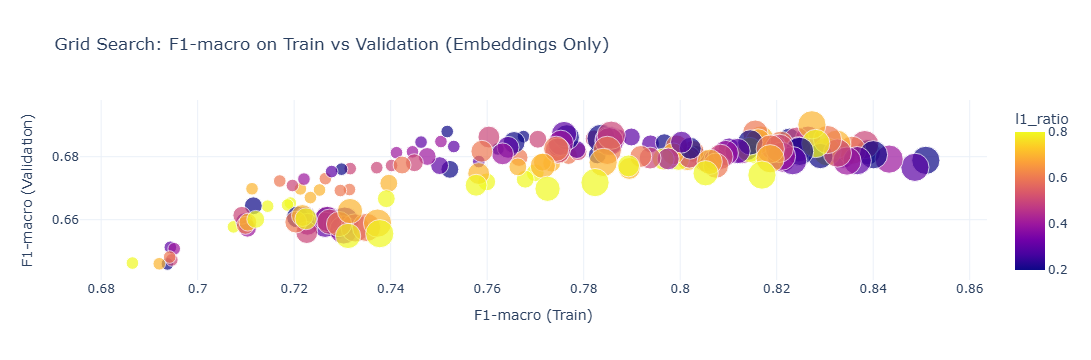

In [ ]:
# -----------------------------
# Scatter plot for hyperparameter search results
# -----------------------------
fig = px.scatter(
    df_results,
    x="f1_train_mean",
    y="f1_val_mean",
    color="l1_ratio",
    size="C",
    hover_data=["threshold", "l1_ratio", "C", "features_left"],
    title="Grid Search: F1-macro on Train vs Validation (Embeddings Only)"
)

# Update axis titles and layout
fig.update_layout(
    xaxis_title="F1-macro (Train)",
    yaxis_title="F1-macro (Validation)",
    template="plotly_white"
)

fig.show()


### 🧩 Grid Search Conclusion

The **best hyperparameters** for the SentenceTransformer embeddings were selected as:  

- **threshold = 0.003**  
- **C = 0.5**  
- **l1_ratio = 0.2**  

These parameters were chosen to balance **model performance** and the **risk of overfitting**.  

With this configuration:  
- **F1-micro on validation ≈ 0.69**  
- **F1-micro on train ≈ 0.75**  

This indicates a strong model with **good generalization**, while still capturing important patterns from the training data.

### 🤖 Model Training & Evaluation

In [ ]:

# -----------------------------
# 1. Label columns
# -----------------------------
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# -----------------------------
# 2. Prepare Validation Data
# -----------------------------
X_emb = val_emb_reduced
y_labeled = val_df[label_cols].values

# -----------------------------
# 3. Cross-Validation on Validation Set
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_pred_all = []

for tr_idx, val_idx in kf.split(X_emb):
    X_tr, X_val_fold = X_emb[tr_idx], X_emb[val_idx]
    y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.2,
            C=0.5,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)
    y_val_pred = clf.predict(X_val_fold)

    y_val_all.append(y_val_fold)
    y_pred_all.append(y_val_pred)

# Aggregate CV predictions
y_val_all = np.vstack(y_val_all)
y_pred_all = np.vstack(y_pred_all)

print("\n=== CV Classification Report (Validation embeddings) ===")
print(classification_report(y_val_all, y_pred_all, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_pred_all, average="micro")
print(f"Aggregated CV micro-F1: {cv_micro:.3f}")

# -----------------------------
# 4. Train/Test Evaluation
# -----------------------------
y_train = train_df[label_cols].values
y_test  = test_df[label_cols].values

clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.2,
        C=0.5,
        random_state=42
    )
)

clf.fit(train_emb_reduced, y_train)

# Evaluate on train
y_train_pred = clf.predict(train_emb_reduced)
print("\n=== TRAIN RESULTS ===")
print(classification_report(y_train, y_train_pred, target_names=label_cols, digits=2))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred, average='macro'):.3f}")

# Evaluate on test
y_test_pred = clf.predict(test_emb_reduced)
print("\n=== TEST RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=label_cols, digits=2))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred, average='macro'):.3f}")



=== CV Classification Report (Validation embeddings) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.61      0.72      0.66       145
          Campus_conditions       0.65      0.73      0.69       108
                 Corruption       0.73      0.74      0.74       133
Academic_Process_Management       0.60      0.75      0.67       130
          Education_Quality       0.67      0.78      0.72       184

                  micro avg       0.65      0.75      0.70       700
                  macro avg       0.65      0.75      0.70       700
               weighted avg       0.65      0.75      0.70       700
                samples avg       0.69      0.80      0.71       700

Aggregated CV micro-F1: 0.697

=== TRAIN RESULTS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.74      0.79      0.76       205
          Campus_conditions       0.68      0.85      0.7

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.



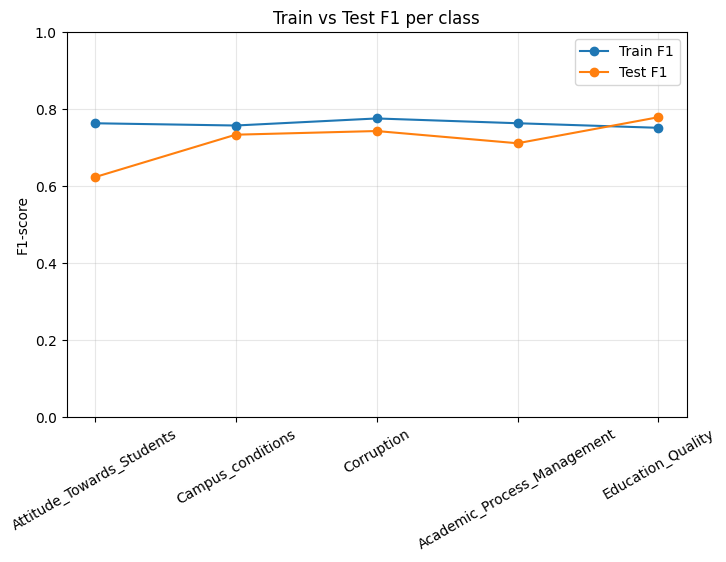

In [ ]:
# List of classes
classes = label_cols

# Compute F1-score for each class individually
f1_train_per_class = [f1_score(y_train[:, i], y_train_pred[:, i]) for i in range(len(classes))]
f1_test_per_class  = [f1_score(y_test[:, i],  y_test_pred[:, i])  for i in range(len(classes))]

# Plot F1-scores for each class (Train vs Test)
plt.figure(figsize=(8,5))
plt.plot(classes, f1_train_per_class, marker='o', label='Train F1')
plt.plot(classes, f1_test_per_class, marker='o', label='Test F1')
plt.ylim(0,1)
plt.ylabel('F1-score')
plt.title('Train vs Test F1 per class')
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### ⚖️ Threshold Optimization

In [ ]:
# -----------------------------

y_labeled = val_df[label_cols].values
# K-Fold CV зі збором proba
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_val_all = []
y_prob_all = []

for tr_idx, val_idx in kf.split(val_emb_reduced):
    X_tr, X_val_fold = val_emb_reduced[tr_idx], val_emb_reduced[val_idx]
    y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.2,
            C=0.5,
            random_state=42
        )
    )

    clf.fit(X_tr, y_tr)

    # Збираємо ймовірності для підбору threshold
    y_val_prob = np.array([est.predict_proba(X_val_fold)[:,1] for est in clf.estimators_]).T

    y_val_all.append(y_val_fold)
    y_prob_all.append(y_val_prob)

# -----------------------------
# Aggregate across folds
# -----------------------------
y_val_all = np.vstack(y_val_all)
y_prob_all = np.vstack(y_prob_all)

# -----------------------------
# Підбір optimal threshold для кожної мітки
# -----------------------------
optimal_thresholds = []

for i in range(y_val_all.shape[1]):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in np.arange(0.1, 0.91, 0.01):
        y_pred_bin = (y_prob_all[:, i] > thresh).astype(int)
        f1 = f1_score(y_val_all[:, i], y_pred_bin)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    optimal_thresholds.append(best_thresh)
    print(f"Label {label_cols[i]}: optimal threshold = {best_thresh:.2f}, F1 = {best_f1:.3f}")

# -----------------------------
# Використання optimal thresholds
# -----------------------------
y_val_pred_opt = np.zeros_like(y_prob_all, dtype=int)
for i, thresh in enumerate(optimal_thresholds):
    y_val_pred_opt[:, i] = (y_prob_all[:, i] > thresh).astype(int)

print("\n=== CV Classification Report WITH OPTIMAL THRESHOLDS ===")
print(classification_report(y_val_all, y_val_pred_opt, target_names=label_cols, zero_division=0))

cv_micro = f1_score(y_val_all, y_val_pred_opt, average="micro")
print(f"Aggregated CV micro-F1 (optimal thresholds): {cv_micro:.4f}")


Label Attitude_Towards_Students: optimal threshold = 0.50, F1 = 0.660
Label Campus_conditions: optimal threshold = 0.53, F1 = 0.718
Label Corruption: optimal threshold = 0.46, F1 = 0.741
Label Academic_Process_Management: optimal threshold = 0.55, F1 = 0.675
Label Education_Quality: optimal threshold = 0.50, F1 = 0.722

=== CV Classification Report WITH OPTIMAL THRESHOLDS ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.61      0.72      0.66       145
          Campus_conditions       0.74      0.69      0.72       108
                 Corruption       0.68      0.82      0.74       133
Academic_Process_Management       0.69      0.66      0.67       130
          Education_Quality       0.67      0.78      0.72       184

                  micro avg       0.67      0.74      0.70       700
                  macro avg       0.68      0.74      0.70       700
               weighted avg       0.67      0.74      0.70       70

### 📉 CV Predicted Probabilities and Threshold Plots

✅ Collected 500 examples from cross-validation.


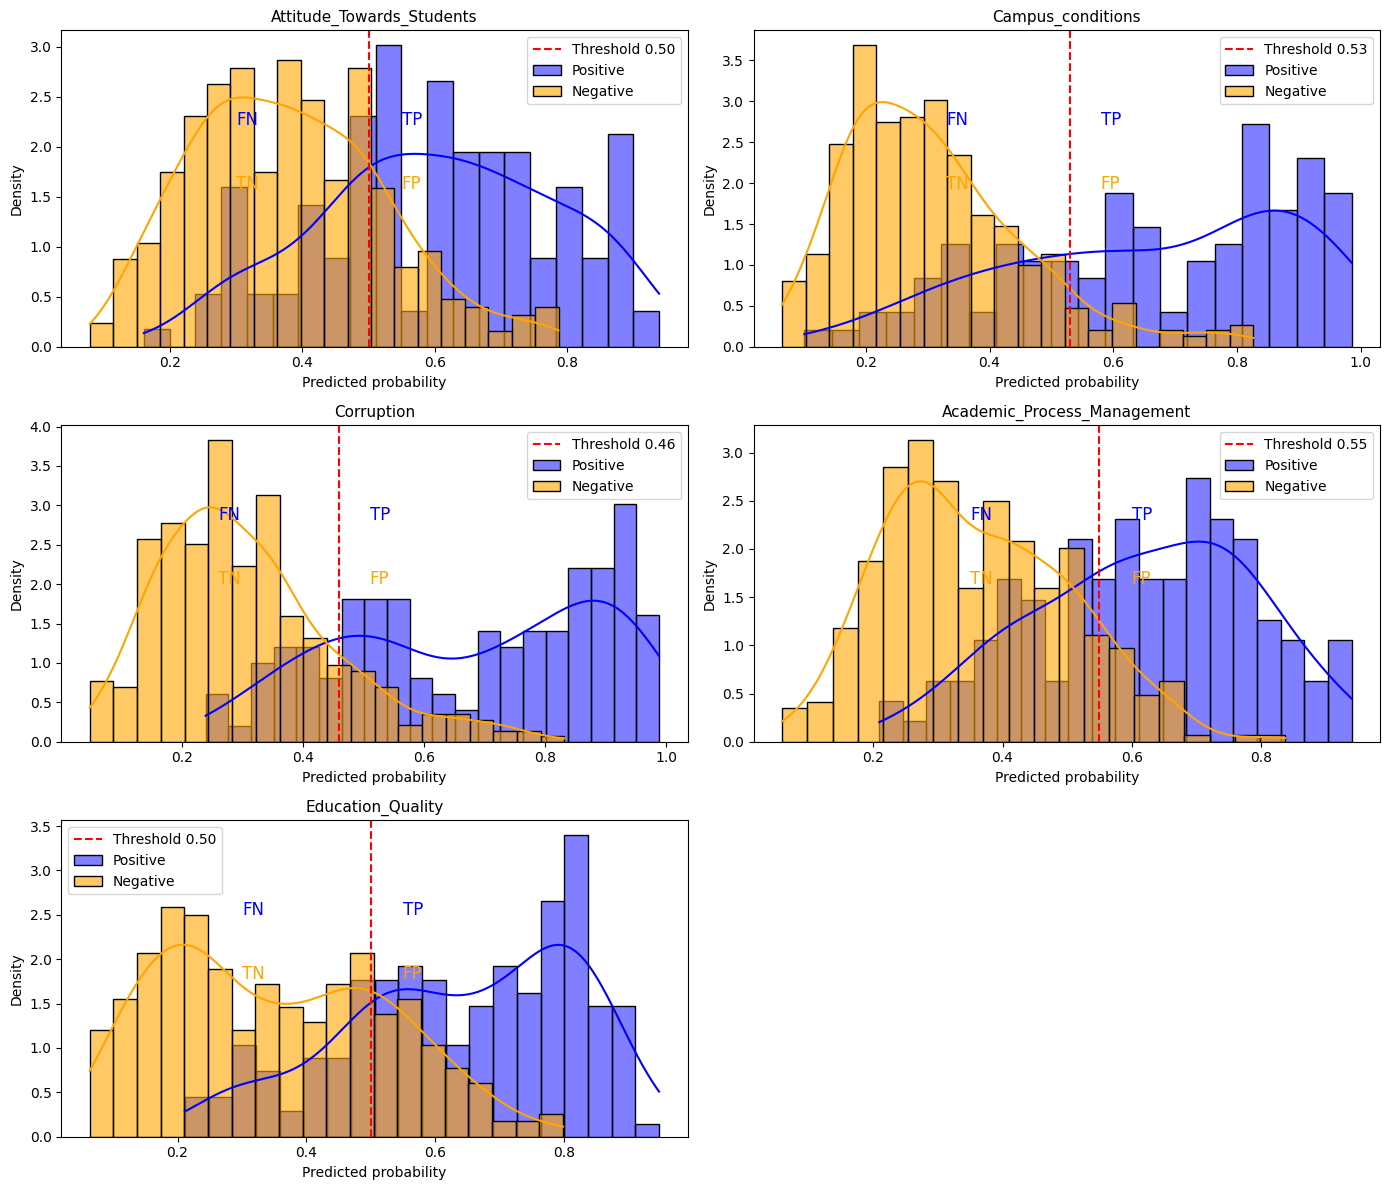

In [ ]:

# -----------------------------
# 1 Parameters
# -----------------------------
# Define the list of target label columns
label_cols = [
    "Attitude_Towards_Students",
    "Campus_conditions",
    "Corruption",
    "Academic_Process_Management",
    "Education_Quality"
]

# Pre-selected optimal thresholds for each class (can be adjusted)
optimal_thresholds = [0.50, 0.53, 0.46, 0.55, 0.50]

# -----------------------------
# 2 Cross-validation to collect predicted probabilities
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_val_all = []
y_prob_all = []

for tr_idx, val_idx in kf.split(val_emb_reduced):
    # Split validation set into training and validation folds
    X_tr, X_val_fold = val_emb_reduced[tr_idx], val_emb_reduced[val_idx]
    y_tr, y_val_fold = y_labeled[tr_idx], y_labeled[val_idx]

    # Initialize One-vs-Rest Logistic Regression classifier
    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            penalty="elasticnet",
            l1_ratio=0.2,
            C=0.5,
            random_state=42
        )
    )
    clf.fit(X_tr, y_tr)

    # Get predicted probabilities for the validation fold
    probs_output = clf.predict_proba(X_val_fold)

    # Handle output format (list of arrays or single 2D array)
    if isinstance(probs_output, list):
        y_prob_fold = np.column_stack([m[:, 1] for m in probs_output])
    else:
        y_prob_fold = probs_output

    # Store probabilities and true labels for this fold
    y_prob_all.append(y_prob_fold)
    y_val_all.append(y_val_fold)

# Concatenate all folds
y_val_all = np.vstack(y_val_all)
y_prob_all = np.vstack(y_prob_all)
print(f"✅ Collected {len(y_val_all)} examples from cross-validation.")

# -----------------------------
# 3 Visualization of predicted probabilities with TP/FP/TN/FN
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, label in enumerate(label_cols):
    ax = axes[i]
    probs = y_prob_all[:, i]
    y_true = y_val_all[:, i]
    threshold = optimal_thresholds[i]

    # Plot histogram for positive and negative samples
    sns.histplot(probs[y_true == 1], color='blue', label='Positive', kde=True, bins=20, stat='density', ax=ax)
    sns.histplot(probs[y_true == 0], color='orange', label='Negative', kde=True, bins=20, stat='density', ax=ax, alpha=0.6)

    # Draw threshold line
    ax.axvline(threshold, color='red', linestyle='--', label=f'Threshold {threshold:.2f}')

    # TP, FN, FP, TN masks (not strictly needed for plotting but for reference)
    TP_mask = (y_true == 1) & (probs >= threshold)
    FN_mask = (y_true == 1) & (probs < threshold)
    FP_mask = (y_true == 0) & (probs >= threshold)
    TN_mask = (y_true == 0) & (probs < threshold)

    # Annotate areas with TP, FN, FP, TN
    ymax = ax.get_ylim()[1]
    ax.text(threshold + 0.05, ymax*0.7, 'TP', color='blue', fontsize=12)
    ax.text(threshold - 0.2, ymax*0.7, 'FN', color='blue', fontsize=12)
    ax.text(threshold + 0.05, ymax*0.5, 'FP', color='orange', fontsize=12)
    ax.text(threshold - 0.2, ymax*0.5, 'TN', color='orange', fontsize=12)

    # Titles and labels
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.legend()

# Remove extra subplot axes if there are fewer labels than subplots
if len(label_cols) < len(axes):
    for j in range(len(label_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 🎯 Evaluate model performance with individual thresholds on train/test sets

In [ ]:
y_train = train_df[label_cols].values
y_test  = test_df[label_cols].values
# ==========================================
# BLOCK 2: Train classifier
# ==========================================
clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        penalty="elasticnet",
        l1_ratio=0.2,
        C=0.5,
        random_state=42
    )
)

clf.fit(train_emb_reduced, y_train)

# ==========================================
# BLOCK 3: Evaluate with optimal thresholds (compact version)
# ==========================================
# Thresholds selected from CV
optimal_thresholds = [0.50, 0.53, 0.46, 0.55, 0.50]

# --- TRAIN SET ---
# Predict probabilities for all classes at once
y_train_prob = clf.predict_proba(train_emb_reduced)  # shape: (n_samples, n_classes)
y_train_pred_opt = (y_train_prob >= optimal_thresholds).astype(int)

print("\n=== TRAIN SET RESULTS (with optimal thresholds) ===")
print(classification_report(y_train, y_train_pred_opt, target_names=label_cols, digits=2, zero_division=0))
print(f"Train Micro F1: {f1_score(y_train, y_train_pred_opt, average='micro'):.3f}")
print(f"Train Macro F1: {f1_score(y_train, y_train_pred_opt, average='macro'):.3f}")

# --- TEST SET ---
y_test_prob = clf.predict_proba(test_emb_reduced)
y_test_pred_opt = (y_test_prob >= optimal_thresholds).astype(int)

print("\n=== TEST SET RESULTS (with optimal thresholds) ===")
print(classification_report(y_test, y_test_pred_opt, target_names=label_cols, digits=2, zero_division=0))
print(f"Test Micro F1: {f1_score(y_test, y_test_pred_opt, average='micro'):.3f}")
print(f"Test Macro F1: {f1_score(y_test, y_test_pred_opt, average='macro'):.3f}")

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save classifier and vectorizer
joblib.dump(clf, "models/logreg_classifier_emb.pkl")
joblib.dump(vectorizer, "models/emb.pkl")  # <- назва змінена

# Print confirmation
print("\n✅ Classifier saved to: models/logreg_classifier_emb.pkl")
print("✅ TF-IDF vectorizer saved to: models/emb.pkl")


=== TRAIN SET RESULTS (with optimal thresholds) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.74      0.79      0.76       205
          Campus_conditions       0.71      0.81      0.76       108
                 Corruption       0.66      0.90      0.76       133
Academic_Process_Management       0.81      0.77      0.79       190
          Education_Quality       0.68      0.84      0.75       184

                  micro avg       0.72      0.82      0.77       820
                  macro avg       0.72      0.82      0.77       820
               weighted avg       0.73      0.82      0.77       820
                samples avg       0.76      0.86      0.78       820

Train Micro F1: 0.766
Train Macro F1: 0.765

=== TEST SET RESULTS (with optimal thresholds) ===
                             precision    recall  f1-score   support

  Attitude_Towards_Students       0.63      0.61      0.62        31
          Campus_co

### **8. 🏆 Model Selection Conclusion**
- Two models were evaluated for **multi-label classification** of student feedback:  
  - **TF-IDF + Logistic Regression**  
  - **Fine-tuned SentenceTransformer (`paraphrase-multilingual-mpnet-base-v2`) + Logistic Regression**

- **TF-IDF Model**:
  - **Train Micro F1:** 0.880  
  - **Test Micro F1:** 0.685  
  - **Train Macro F1:** 0.885  
  - **Test Macro F1:** 0.681  
  - Shows **high training performance** but a **significant drop on test set**, indicating **overfitting**.  
  - Captures **lexical patterns** well but lacks **semantic/contextual understanding**.

- **Fine-Tuned Embedding Model**:
  - **Train Micro F1:** 0.766  
  - **Test Micro F1:** 0.726  
  - **Train Macro F1:** 0.765  
  - **Test Macro F1:** 0.718  
  - Demonstrates **more stable and generalizable performance**.  
  - Leverages **semantic representations** from the transformer for **better generalization** and **balanced per-label performance**.

- **Final Decision**:
  - The **fine-tuned SentenceTransformer model** was selected as the **final model**.  
  - Achieves **higher generalization** and **better semantic understanding** than TF-IDF.  
  - **Individual threshold optimization** improves per-label **precision and recall**.  
  - **Final Test Performance**:  
    - **Micro F1:** 0.726  
    - **Macro F1:** 0.718  
  - Ensures a **robust and interpretable classifier** suitable for **real-world deployment**.
